In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
import matplotlib.pyplot as plt

@dataclass(frozen=True)
class Example:
    x: torch.Tensor
    target_y: torch.Tensor

def get_training_data() -> list[Example]:
    return [
        Example(
            x=torch.Tensor([1.0, 2.0, 0.0, 1.0]), 
            target_y=torch.Tensor([0.0, 1.0, 0.0]),
        ),
        Example(
            x=torch.Tensor([-1.0, 0.0, 2.0, 1.0]), 
            target_y=torch.Tensor([1.0, 0.0, 0.0]),
        ),
        Example(
            x=torch.Tensor([0.0, 3.0, 1.0, 0.0]), 
            target_y=torch.Tensor([0.0, 0.0, 1.0]),
        ),
    ]

In [3]:
from typing import Any

# 3 layers MLP (residual connection + layer norm + Xavier initialization)
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        # layer 1: input -> hidden layer 1
        self.fc_in = nn.Linear(input_dim, hidden_dim)
        # layer 2: hidden layer 1 -> hidden layer 2 (with layer norm + residual connection)
        self.fc_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        # layer 3: hidden layer 2 -> output (logits)
        self.fc_out = nn.Linear(hidden_dim, num_classes)
        # Initialize params (Xavier truncated normal)， not required for the simple training data used for this demo
        self._init_weights()

    # Xavier truncated normal initialization
    def _init_weights(self):
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                #standard std = 1 / sqrt(dim_in)
                std = 1.0 / (layer.weight.size(1) ** 0.5)
                #trunc norm [-3 * std, 3 * std]
                nn.init.trunc_normal_(layer.weight, std=std, a=-3.0, b=3.0)
                #init bias as zero
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #layer 1: linear(x) -> relu
        x = F.relu(self.fc_in(x))
        #layer 2: (Post-LN) linear(x) -> layer norm -> relu -> residual connection
        out = x + F.relu(self.norm(self.fc_hidden(x)))
        #layer 3: linear(x)
        logits = self.fc_out(out)
        return logits



In [9]:
def train_model(
    model: nn.Module,
    training_data: list[Example],
    learning_rate: float = 0.01,
    num_steps: int = 100
):
    x = torch.stack([example.x for example in training_data])
    target_y = torch.stack([example.target_y for example in training_data])

    loss_history = []
    cross_entropy = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

    for step in range(num_steps):
        logits = model(x)
        loss = cross_entropy(logits, target_y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss)

        if (step + 1) % 10 == 0 or step == 0:
            print(f"Step [{step + 1:03d}/{num_steps}], Loss: {loss.item():.4f}")

    return loss_history


Step [001/100], Loss: 2.3531
Step [010/100], Loss: 1.0220
Step [020/100], Loss: 0.5228
Step [030/100], Loss: 0.2461
Step [040/100], Loss: 0.1195
Step [050/100], Loss: 0.0532
Step [060/100], Loss: 0.0261
Step [070/100], Loss: 0.0153
Step [080/100], Loss: 0.0105
Step [090/100], Loss: 0.0080
Step [100/100], Loss: 0.0064


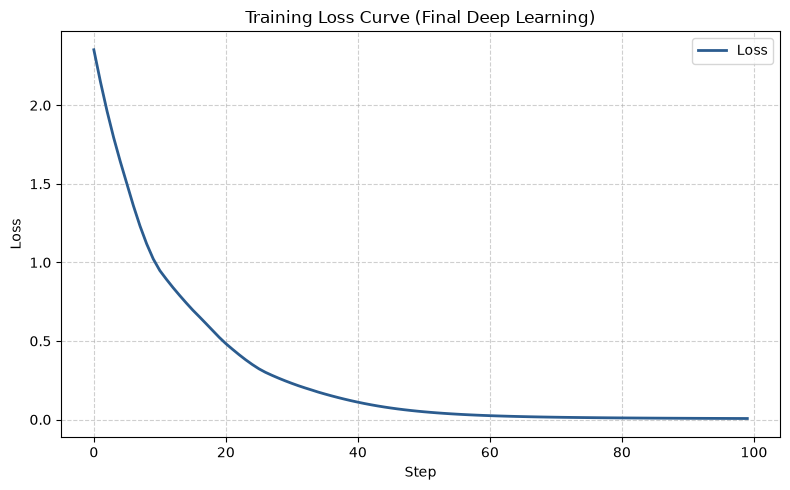

In [11]:
def plot_training_curve(
    losses: list[float], title: str = "Training Loss Curve (Final Deep Learning)"
):
    plt.figure(figsize=(8, 5))
    plt.plot(range(len(losses)), losses, color="#2b5c8f", linewidth=2, label="Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

torch.manual_seed(42)

training_data = get_training_data()
input_dim = len(training_data[0].x)
num_classes = len(training_data[0].target_y)
model = MLP(input_dim=input_dim, hidden_dim=8, num_classes=num_classes)
loss_history = train_model(model=model, training_data=training_data)

plot_training_curve([loss.item() for loss in loss_history])